In [ ]:
%pip install matplotlib
%pip install tensorflow
%pip install scikit-learn
%pip install numpy
%pip install seaborn
%pip install pandas pyarrow tqdm

## Global configuration

In [1]:
dataset_root = "../datasets"

import sys
sys.path.append('./lib')

## Dataset loading and preparation

In [10]:
%load_ext autoreload
%autoreload 2

from preprocessing import fit_preprocessor, extract_features
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pyarrow.dataset as ds
import pyarrow.compute as pc

dataset = ds.dataset(f"{dataset_root}/malware.parquet", format="parquet")
print("Loading dataset...")
filt = (
    pc.starts_with(pc.field("meta.sample.id"), "25090")    # use meta.sample.id to get only a single day 2025-09-01
)

df = dataset.to_table(
    filter=filt
).to_pandas()
print("Extracting features...")
_df = extract_features(df)
print("Fitting preprocessor...")
pipeline = fit_preprocessor(_df)
print("Done.")
_df

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading dataset...
Extracting features...
Fitting preprocessor...
Done.


,bs,ps,br,pr,td,tls.cver,tls.sver,tls.scs,0000,0005,...,tls.rec.10,tls.rec.11,tls.rec.12,tls.rec.13,tls.rec.14,tls.rec.15,tls.rec.16,tls.rec.17,tls.rec.18,tls.rec.19
0,1262.0,13.0,8316.0,12.0,0.941528,0303,0303,C030,1,0,...,-33,33,3903,0,0,0,0,0,0,0
1,49974.0,64.0,39987.0,54.0,128.561234,0303,0303,C030,1,1,...,-462,-9401,1270,-469,-7637,781,-469,-7637,781,-469
2,35832.0,48.0,31235.0,40.0,138.264477,0303,0303,C030,1,1,...,-469,-7637,781,-469,-7540,781,-445,-3616,12066,-445
3,4529.0,14.0,8280.0,14.0,1.195099,0303,0303,C030,1,0,...,33,3751,0,0,0,0,0,0,0,0
4,4035.0,14.0,4910.0,13.0,0.749950,0303,0303,C030,1,0,...,33,379,37,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396328,2367.0,5.0,5844.0,9.0,8.714850,0303,0303,1302,0,0,...,0,0,0,0,0,0,0,0,0,0
396329,2367.0,5.0,5844.0,9.0,8.714850,0303,0303,1302,0,0,...,0,0,0,0,0,0,0,0,0,0
396330,2367.0,5.0,5844.0,9.0,8.714850,0303,0303,1302,0,0,...,0,0,0,0,0,0,0,0,0,0
396331,2367.0,5.0,5844.0,9.0,8.714850,0303,0303,1302,0,0,...,0,0,0,0,0,0,0,0,0,0


## Traing a collection of AEs


In [ ]:
from auto_train import train_autoencoder
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from data_helper import get_families, per_family_split
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

print(f" Getting family splits...")
MIN_SAMPLES = 100 
MAX_SAMPLES = 10_000
families = get_families(df)
splits = per_family_split(df, families, test_size=0.2)

models = {}   # <-- store trained models here
for family, (train_df, test_df) in splits.items():
    print(f"\nFamily: {family}")
    print(f"  ⎯Train size: {len(train_df)}")
    print(f"  ⎯Test size:  {len(test_df)}")

    if len(train_df) > MIN_SAMPLES:
        print("  Training autoencoder...")

        if len(train_df) > MAX_SAMPLES:
            train_df = train_df.sample(MAX_SAMPLES, random_state=1234)
        if len(test_df) > MAX_SAMPLES:
            test_df = test_df.sample(MAX_SAMPLES, random_state=1234)

        X_train = pipeline.transform(extract_features(train_df))
        X_test  = pipeline.transform(extract_features(test_df))

        model = train_autoencoder(X_train, X_test, 10, max_epochs=5)

        # Store trained model under family key
        models[family] = model
        print(f"  Model stored under key: '{family}'")

    else:
        print("  Not enough samples, skipping.")
        models[family] = None  # optional: indicate skipped families

models

 Getting family splits...

Family: ades_stealer
  ⎯Train size: 1106
  ⎯Test size:  277
  Training autoencoder...
train shape=(2212, 157)
test shape=(554, 157)
Epoch 1/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3829 - val_loss: 0.1127
Epoch 2/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1045 - val_loss: 0.0976
Epoch 3/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0936 - val_loss: 0.0916
Epoch 4/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0905 - val_loss: 0.0904
Epoch 5/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0895 - val_loss: 0.0893
Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0886 - val_loss: 0.0883
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0868 - val_loss: 0.0861
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0844 - val_loss: 0.0826
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0815 - val_loss: 0.0809
Epoch 5/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0803 - val_loss: 0.

KeyboardInterrupt: 

## Evaluation of AEs using the input dataset

In [12]:
# ---------------------------------------------------------------------
# Helper: compute AE reconstruction error
# ---------------------------------------------------------------------
def compute_recon_error(model, X):
    """Compute reconstruction error for autoencoder model."""
    recon = model.predict(X)
    return np.mean((X - recon) ** 2, axis=1)


# ---------------------------------------------------------------------
# EVALUATION: model (trained on fam A) → tested on fam B
# ---------------------------------------------------------------------
results = []   # rows for DataFrame

print("\n\n=== Evaluating models across all families ===")

# prepare list of families we will evaluate on
families = list(splits.keys())

for model_family, model in models.items():

    if model is None:
        print(f"Skipping evaluation for '{model_family}' (no trained model).")
        continue

    print(f"\nEvaluating model trained on: {model_family}")
    print(model)

    # Baseline: reconstruction error on its own family
    train_df, test_df = splits[model_family]
    X_self = pipeline.transform(extract_features(test_df))
    err_self = compute_recon_error(model.model, X_self)

    self_mean = np.mean(err_self)
    self_std  = np.std(err_self) + 1e-9

    # Evaluate on all other families
    for target_family in families:
        _, target_test = splits[target_family]
        X_target = pipeline.transform(extract_features(target_test))

        err = compute_recon_error(model.model, X_target)

        row = {
            "model_family": model_family,
            "target_family": target_family,
            "mean": float(np.mean(err)),
            "std": float(np.std(err)),
            "median": float(np.median(err)),
            "p90": float(np.percentile(err, 90)),
            "p95": float(np.percentile(err, 95)),
            "p99": float(np.percentile(err, 99)),
            "delta_mean": float(np.mean(err) - self_mean),
            "z_mean": float((np.mean(err) - self_mean) / self_std),
        }

        results.append(row)

# Convert to DataFrame
df_eval = pd.DataFrame(results)
print("\nEvaluation results:\n", df_eval.head())      



=== Evaluating models across all families ===

Evaluating model trained on: ades_stealer
AETrainResult(model=<Functional name=functional, built=True>, avg_error=np.float64(5.508924837893016e-05), std_error=np.float64(0.00016737920282832184))
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

d:\GitHub\AutoFedProfile\notebooks\./lib\preprocessing.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

d:\GitHub\AutoFedProfile\notebooks\./lib\preprocessing.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━

...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


d:\GitHub\AutoFedProfile\notebooks\./lib\preprocessing.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━

d:\GitHub\AutoFedProfile\notebooks\./lib\preprocessing.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Evaluation results:
    model_family target_family      mean       std    median       p90  \
0  ades_stealer  ades_stealer  0.000055  0.000167  0.000014  0.000113   
1  ades_stealer    agenttesla  0.007673  0.0212

##  Heatmap Visualization


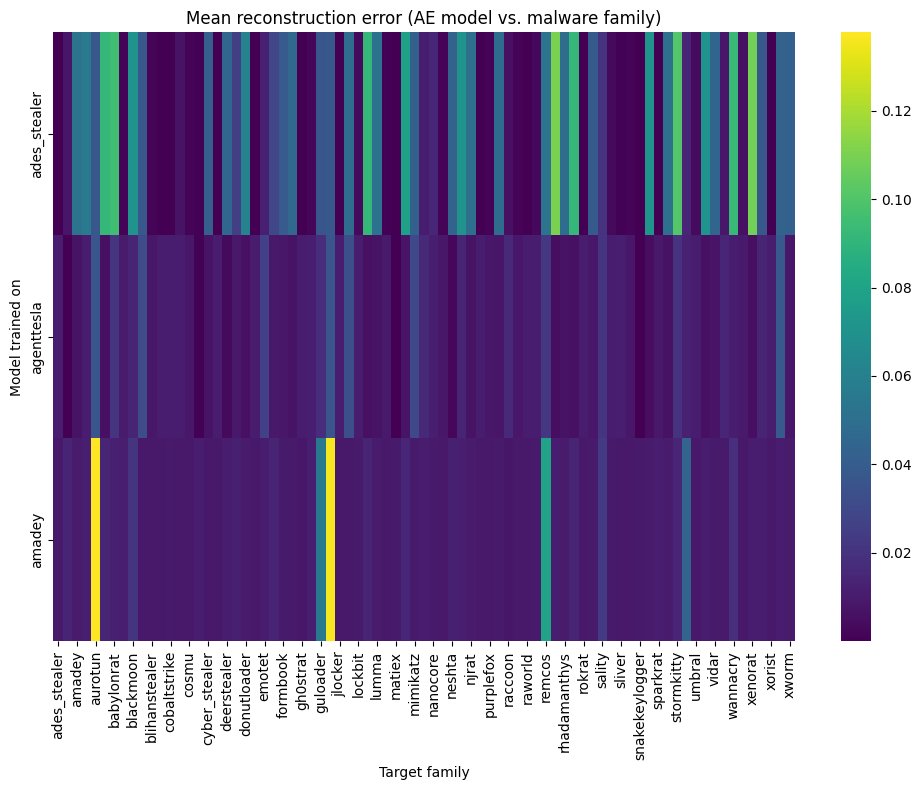

In [13]:
pivot_mean = df_eval.pivot(index="model_family", columns="target_family", values="mean")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_mean, annot=False, cmap="viridis")
plt.title("Mean reconstruction error (AE model vs. malware family)")
plt.xlabel("Target family")
plt.ylabel("Model trained on")
plt.tight_layout()
plt.show()

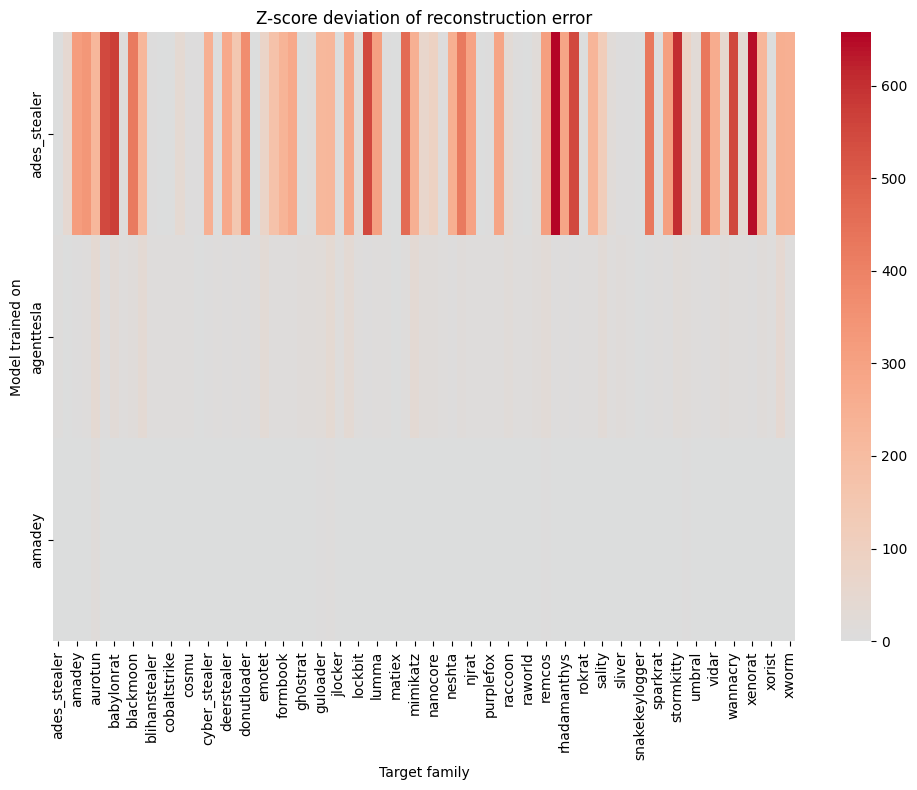

In [14]:
pivot_z = df_eval.pivot(index="model_family", columns="target_family", values="z_mean")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_z, annot=False, cmap="coolwarm", center=0)
plt.title("Z-score deviation of reconstruction error")
plt.xlabel("Target family")
plt.ylabel("Model trained on")
plt.tight_layout()
plt.show()